In [1]:
import argparse
import at
from pySC import disable_pySC_rich
from pySC.configuration.generation import generate_SC
from pySC.tuning.response_measurements import measure_OrbitResponseMatrix
from pySC.tuning.response_measurements import measure_RFFrequencyOrbitResponse
from pySC.tuning.averaging import get_average_orbit

from run_pyloco_from_model import run_pyloco_from_model
from set_correction import last_by_sorted_key, get_quads_block, set_correction
import os
import h5py
from analyze_ring import analyze_ring
import matplotlib.pyplot as plt
import numpy as np
disable_pySC_rich()
scale_errors = 1
seed = 1
yaml_filepath = 'betamodel_conf_ideal.yaml'
SC = generate_SC(yaml_filepath, seed=1, scale_errors=scale_errors, sigma_truncate=3)
QD3 =at.get_refpts(SC.lattice.design, 'QD3[AE]*')
QF4 =at.get_refpts(SC.lattice.design, 'QF4[ABDE]*')
QD5 =at.get_refpts(SC.lattice.design, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
used_bpms_ords = at.get_refpts(SC.lattice.design, at.elements.Monitor)

09 Nov 2025, 01:20:47 | WARNING | 'error_table' is missing in the configuration file: betamodel_conf_ideal.yaml. It will be empty!
09 Nov 2025, 01:20:47 | INFO | Loading AT lattice from betamodel.mat


/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/analyze_ring.py:174: SyntaxWarning: invalid escape sequence '\m'
  plot_data(s_pos, orbit_x * 1e6, "s [m]", "Horizontal orbit $[\mu\mathrm{m}]$", "Horizontal closed orbit")
/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/analyze_ring.py:175: SyntaxWarning: invalid escape sequence '\m'
  plot_data(s_pos, orbit_y * 1e6, "s [m]", "Vertical orbit $[\mu\mathrm{m}]$", "Vertical closed orbit")
/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


09 Nov 2025, 01:20:51 | INFO | Configuring magnets...
09 Nov 2025, 01:20:51 | INFO | Found 514 (quadrupoles) matching regex '^QD|^QF'
09 Nov 2025, 01:20:51 | INFO | Found 192 (sextupoles) matching regex '^SJ|^SF|^SD|^SI'
09 Nov 2025, 01:20:51 | INFO | Found 64 (octupoles) matching regex '^O'
09 Nov 2025, 01:20:51 | INFO | Found 96 (correctors) matching regex '^SH'
09 Nov 2025, 01:20:51 | INFO | Configuring BPMs...
09 Nov 2025, 01:20:51 | INFO | Found 320 (bpms) matching regex '^BPM'
09 Nov 2025, 01:20:51 | WARNING | No orbit_noise was found for bpms: bpms.
09 Nov 2025, 01:20:51 | WARNING | No tbt_noise was found for bpms: bpms.
09 Nov 2025, 01:20:51 | WARNING | No calibration_error was found for bpms: bpms.
09 Nov 2025, 01:20:51 | INFO | Configuring rf...
09 Nov 2025, 01:20:51 | INFO | Found 13 (main) matching regex '^CAV'
09 Nov 2025, 01:20:51 | INFO | Configuring supports...
09 Nov 2025, 01:20:51 | INFO | Resolving supports: looping through L0
09 Nov 2025, 01:20:51 | INFO | Configuri

In [2]:
elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   3.7926 µm
RMS vertical orbit           :   0.0000 µm
RMS horizontal beta beating  :   0.0000 %
RMS vertical beta beating    :   0.0000 %
RMS horizontal dispersion err:   0.0000 mm
RMS vertical dispersion err  :   0.0000 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 140.8391273379139 emittance_v 0.0
----------------------------------------------------------------------


In [3]:
# Apply error to one quad
from pySC import generate_SC

# needs betamodel.mat
SC = generate_SC('betamodel_conf_ideal.yaml', seed=1, sigma_truncate=3)

quad_indices_err = [42, 1781]
errors = [0.05, 0.05]   # 5% error
for quad_index, error in zip(quad_indices_err, errors):
    magnet_name = SC.magnet_settings.index_mapping[quad_index]
    SC.magnet_settings.magnets[magnet_name]._links[0].error.factor = 1. + error
    SC.magnet_settings.magnets[magnet_name].update()

elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

09 Nov 2025, 01:20:55 | WARNING | 'error_table' is missing in the configuration file: betamodel_conf_ideal.yaml. It will be empty!
09 Nov 2025, 01:20:55 | INFO | Loading AT lattice from betamodel.mat


/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


09 Nov 2025, 01:20:58 | INFO | Configuring magnets...
09 Nov 2025, 01:20:58 | INFO | Found 514 (quadrupoles) matching regex '^QD|^QF'
09 Nov 2025, 01:20:58 | INFO | Found 192 (sextupoles) matching regex '^SJ|^SF|^SD|^SI'
09 Nov 2025, 01:20:58 | INFO | Found 64 (octupoles) matching regex '^O'
09 Nov 2025, 01:20:58 | INFO | Found 96 (correctors) matching regex '^SH'
09 Nov 2025, 01:20:59 | INFO | Configuring BPMs...
09 Nov 2025, 01:20:59 | INFO | Found 320 (bpms) matching regex '^BPM'
09 Nov 2025, 01:20:59 | WARNING | No orbit_noise was found for bpms: bpms.
09 Nov 2025, 01:20:59 | WARNING | No tbt_noise was found for bpms: bpms.
09 Nov 2025, 01:20:59 | WARNING | No calibration_error was found for bpms: bpms.
09 Nov 2025, 01:20:59 | INFO | Configuring rf...
09 Nov 2025, 01:20:59 | INFO | Found 13 (main) matching regex '^CAV'
09 Nov 2025, 01:20:59 | INFO | Configuring supports...
09 Nov 2025, 01:20:59 | INFO | Resolving supports: looping through L0
09 Nov 2025, 01:20:59 | INFO | Configuri

In [4]:
# pyLOCO

# ORM, dispersion and BPM noise measurements

HCORR = SC.tuning.HCORR
VCORR = SC.tuning.VCORR
orm = measure_OrbitResponseMatrix(SC, HCORR, VCORR, dkick = 100e-6, normalize=False, bipolar=True) #[BPMS x cor] in meter
eta =  measure_RFFrequencyOrbitResponse(SC, delta_frf =200, normalize = False, bipolar=True)
etax = eta[:len(eta)//2] # meter
etay = eta[len(eta)//2:] # meter
x, y, x_std, y_std = get_average_orbit(SC, 100)

sigma_w = np.concatenate((x_std, y_std))

x_std = np.ones_like(used_bpms_ords)
y_std = np.ones_like(used_bpms_ords)
sigma_w = np.concatenate((x_std, y_std))


Calculating response matrix


Plot saved to: data/orms_comparison.png


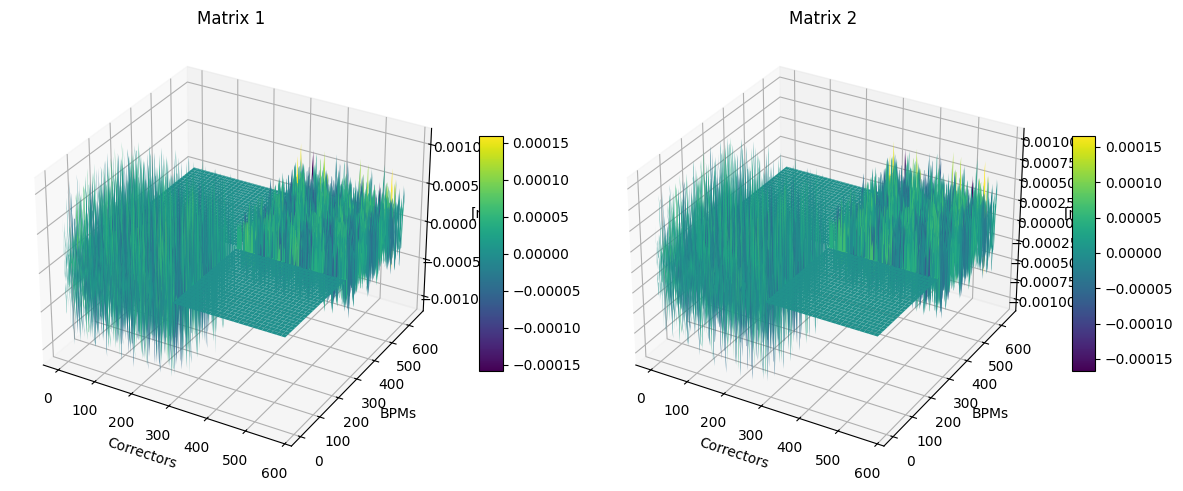

RMS difference between model and measured ORM: 5.402e-05 m


In [ ]:
from pyLOCO.analysis import plot_matrices
from pyloco_config import FitInitConfig, RMConfig, fixed_parameters
from pyLOCO.response_matrix import response_matrix
ring = at.load_lattice('betamodel.mat', use='betamodel')
ring.disable_6d()

cor_indices = at.get_refpts(ring, 'S[HFDIJ]*')
Corords = [cor_indices, cor_indices]

CMstep = [[100e-6] * len(Corords[0]), [100e-6] * len(Corords[1])]


fit_cfg = FitInitConfig()
includeDispersion = False
HCMCoupling = np.zeros(len(Corords[0]))
VCMCoupling = np.zeros(len(Corords[1]))

cfg = RMConfig(
    dkick=CMstep,
    bpm_ords=used_bpms_ords,
    cm_ords=Corords,
    HCMCoupling=HCMCoupling,
    VCMCoupling=VCMCoupling,
    rfStep=fixed_parameters.rfstep,
    includeDispersion=includeDispersion
)

# --- Compute model ORM ---

orm_model = response_matrix(ring, config=cfg)

rms_diff = np.sqrt(np.mean((orm_model - orm)**2))
os.makedirs("data", exist_ok=True)
plot_matrices(orm_model, orm, titles=None, cmap='viridis', plot_type='3d', save_path="data/orms_comparison.png")

print(f"RMS difference between model and measured ORM: {rms_diff:.3e} m")

Before_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   3.9411 µm
RMS vertical orbit           :   0.0000 µm
RMS horizontal beta beating  :  18.3214 %
RMS vertical beta beating    :   6.5040 %
RMS horizontal dispersion err:  16.5259 mm
RMS vertical dispersion err  :   0.0000 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.62023990e+01 2.73150298e+01 3.67463804e-03]
Chromaticity                 : [8.00918307e+00 7.35822382e+00 4.64577949e-03]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 252.83332289459173 emittance_v 0.0
----------------------------------------------------------------------

==== Iteration 1/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 1)...
[calculate_quads_jacobian] Logs saved to '/User

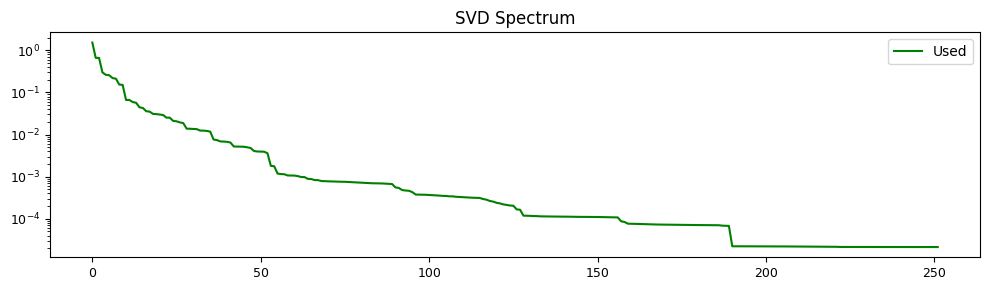

  LM inner 1: chi² 4.0359e-10 (previous 5.8392e-09), λ=0.001
Chi² after correction: 4.0359e-10

==== Iteration 2/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 2)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 4.0359e-10


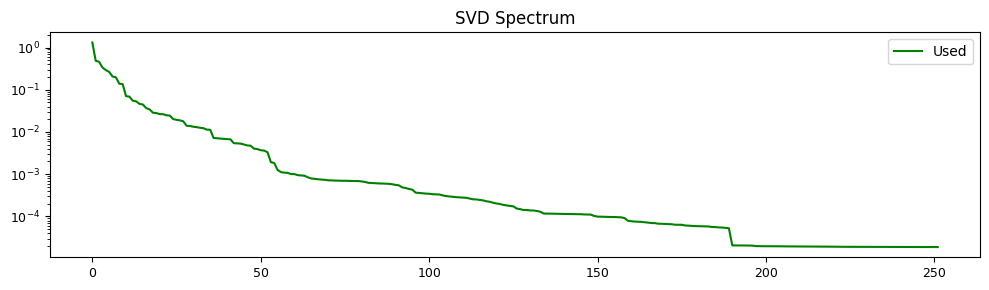

  LM inner 1: chi² 1.3308e-11 (previous 4.0359e-10), λ=0.001
Chi² after correction: 1.3308e-11

==== Iteration 3/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 3)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 1.3308e-11


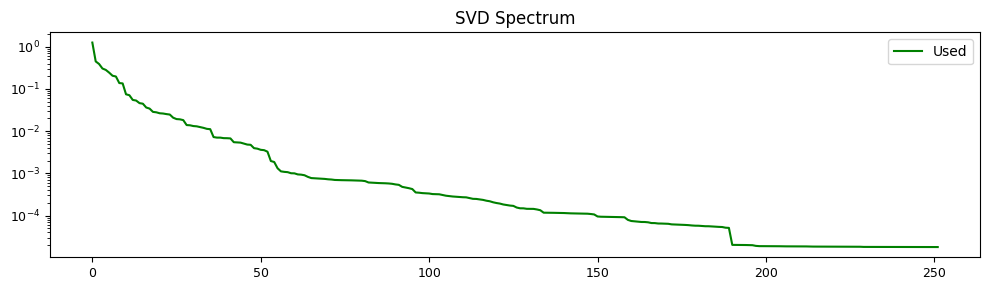

  LM inner 1: chi² 8.3119e-12 (previous 1.3308e-11), λ=0.001
Chi² after correction: 8.3119e-12

==== Iteration 4/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 4)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.3119e-12


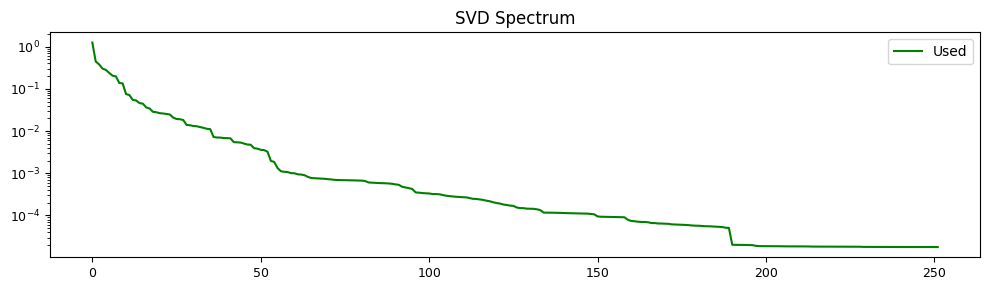

  LM inner 1: chi² 8.2967e-12 (previous 8.3119e-12), λ=0.001
Chi² after correction: 8.2967e-12

==== Iteration 5/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 5)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2967e-12


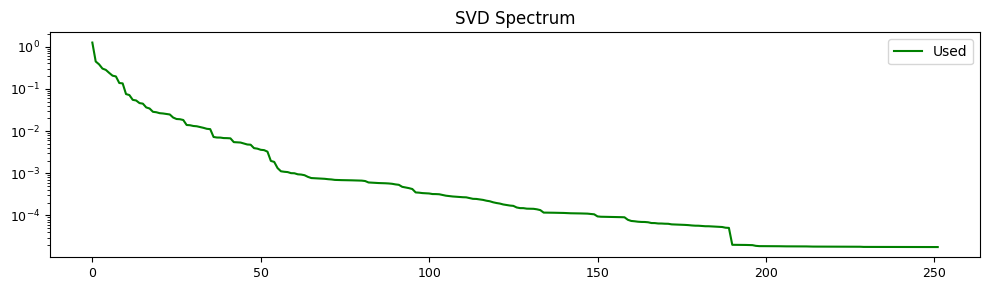

  LM inner 1: chi² 8.2877e-12 (previous 8.2967e-12), λ=0.001
Chi² after correction: 8.2877e-12

==== Iteration 6/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 6)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2877e-12


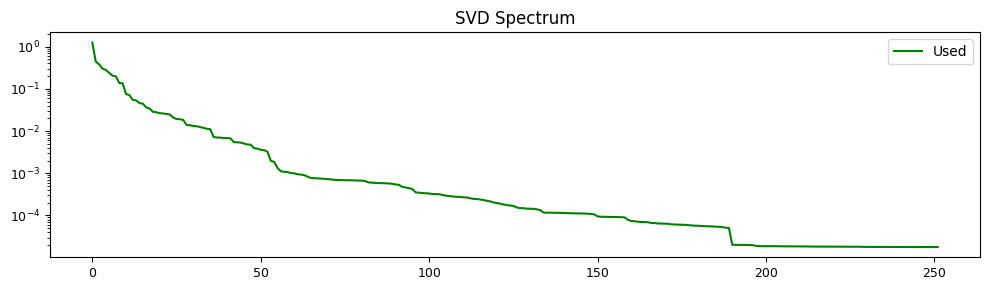

  LM inner 1: chi² 8.2804e-12 (previous 8.2877e-12), λ=0.001
Chi² after correction: 8.2804e-12

==== Iteration 7/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 7)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2804e-12


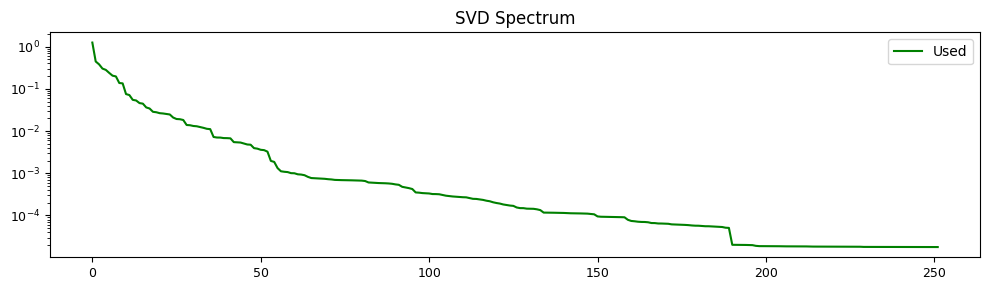

  LM inner 1: chi² 8.2746e-12 (previous 8.2804e-12), λ=0.001
Chi² after correction: 8.2746e-12

==== Iteration 8/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 8)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2746e-12


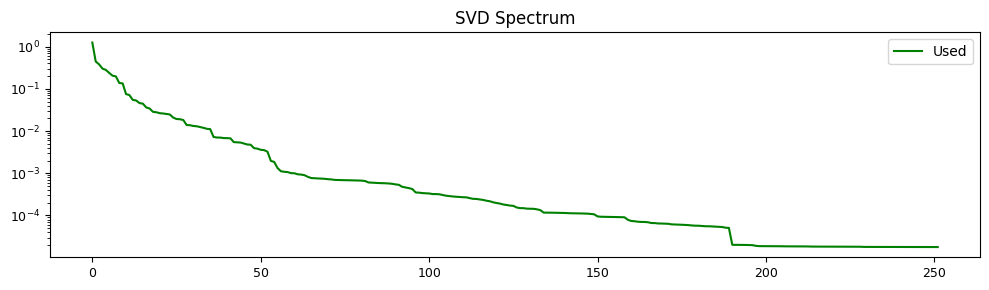

  LM inner 1: chi² 8.2699e-12 (previous 8.2746e-12), λ=0.001
Chi² after correction: 8.2699e-12

==== Iteration 9/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 9)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2699e-12


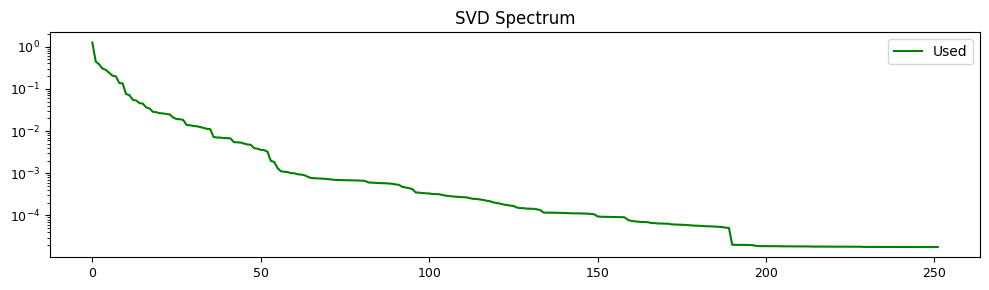

  LM inner 1: chi² 8.2660e-12 (previous 8.2699e-12), λ=0.001
Chi² after correction: 8.2660e-12

==== Iteration 10/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 10)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2660e-12


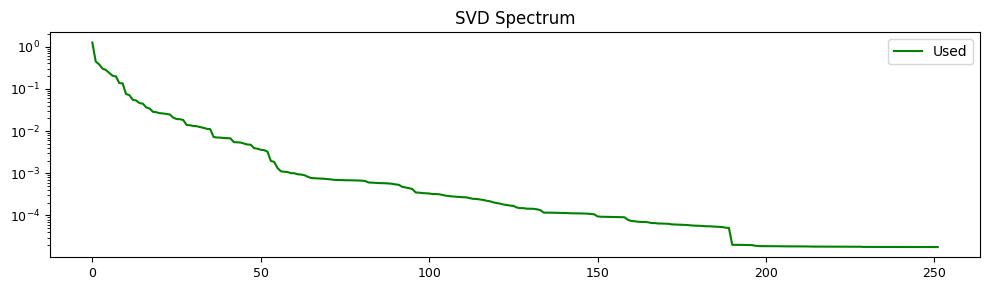

  LM inner 1: chi² 8.2628e-12 (previous 8.2660e-12), λ=0.001
Chi² after correction: 8.2628e-12

==== Iteration 11/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 11)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2628e-12


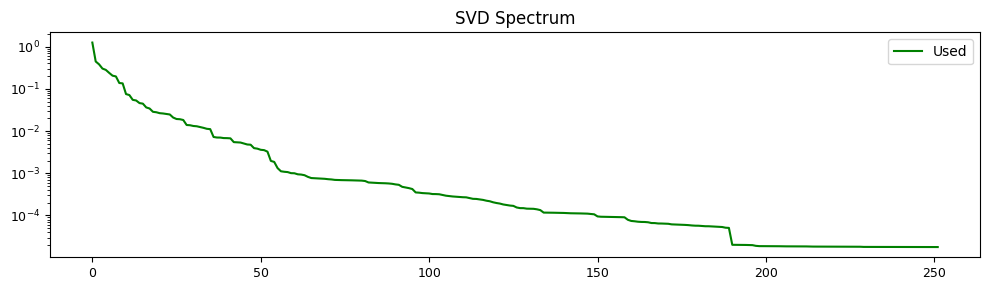

  LM inner 1: chi² 8.2602e-12 (previous 8.2628e-12), λ=0.001
Chi² after correction: 8.2602e-12

==== Iteration 12/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 12)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2602e-12


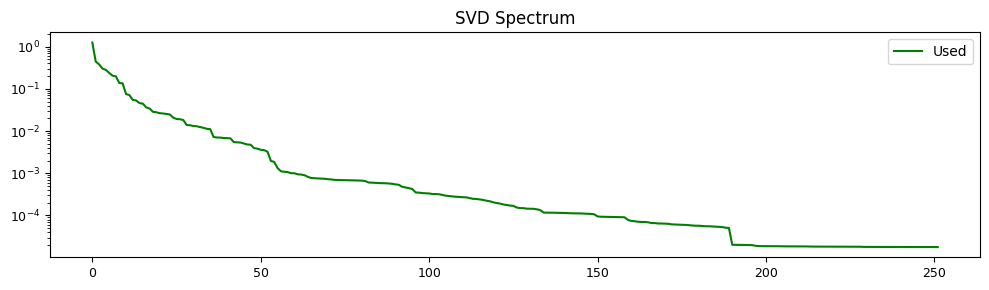

  LM inner 1: chi² 8.2580e-12 (previous 8.2602e-12), λ=0.001
Chi² after correction: 8.2580e-12

==== Iteration 13/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 13)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2580e-12


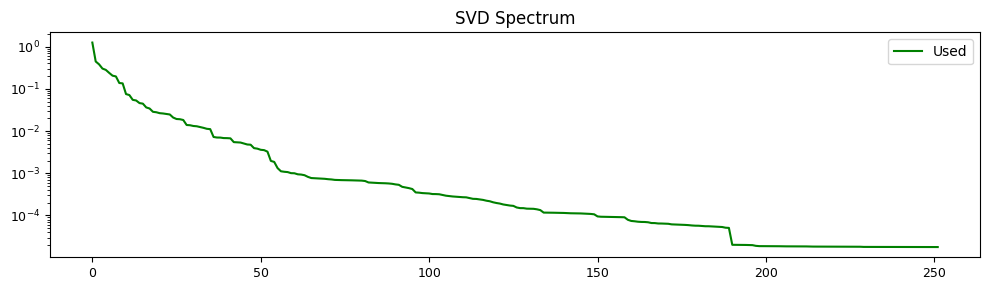

  LM inner 1: chi² 8.2562e-12 (previous 8.2580e-12), λ=0.001
Chi² after correction: 8.2562e-12

==== Iteration 14/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 14)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2562e-12


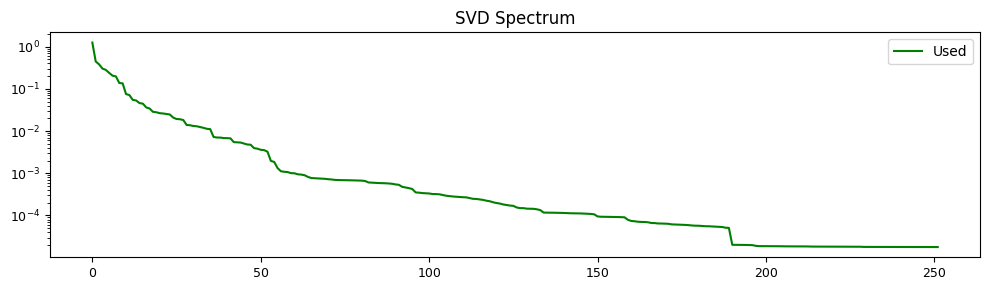

  LM inner 1: chi² 8.2547e-12 (previous 8.2562e-12), λ=0.001
Chi² after correction: 8.2547e-12

==== Iteration 15/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 15)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2547e-12


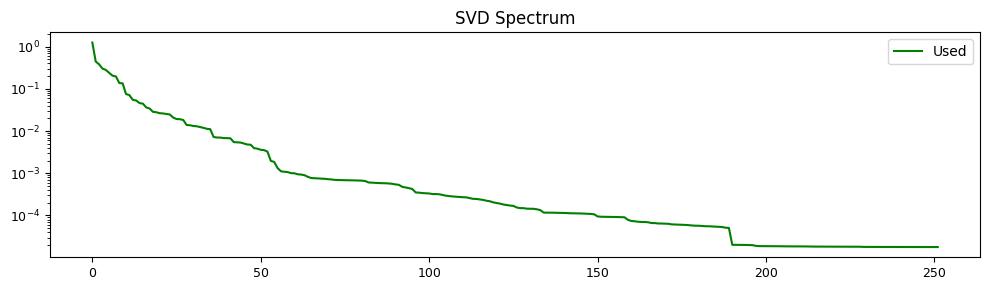

  LM inner 1: chi² 8.2535e-12 (previous 8.2547e-12), λ=0.001
Chi² after correction: 8.2535e-12

==== Iteration 16/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 16)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2535e-12


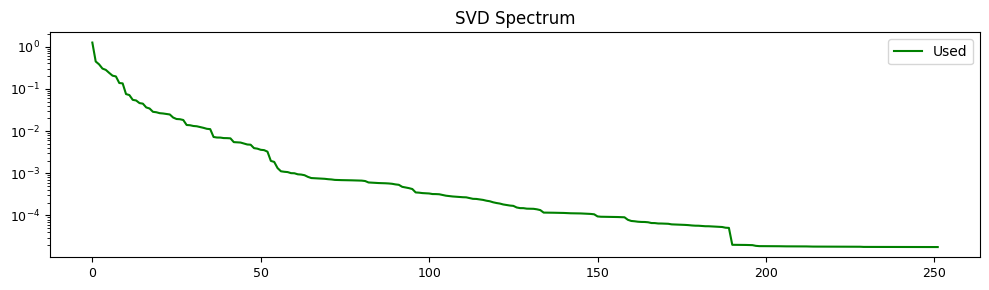

  LM inner 1: chi² 8.2524e-12 (previous 8.2535e-12), λ=0.001
Chi² after correction: 8.2524e-12

==== Iteration 17/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 17)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2524e-12


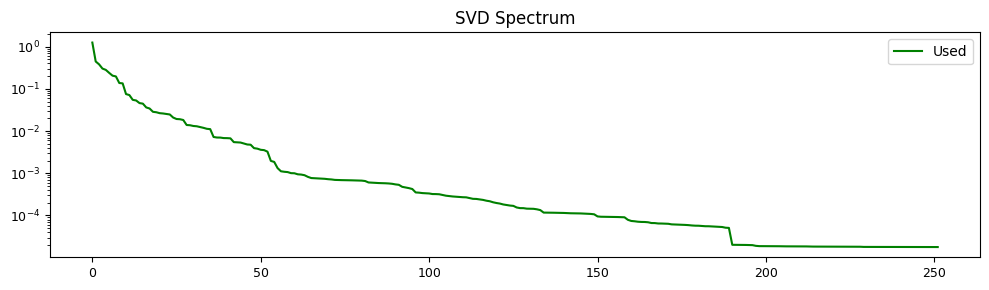

  LM inner 1: chi² 8.2515e-12 (previous 8.2524e-12), λ=0.001
Chi² after correction: 8.2515e-12

==== Iteration 18/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 18)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2515e-12


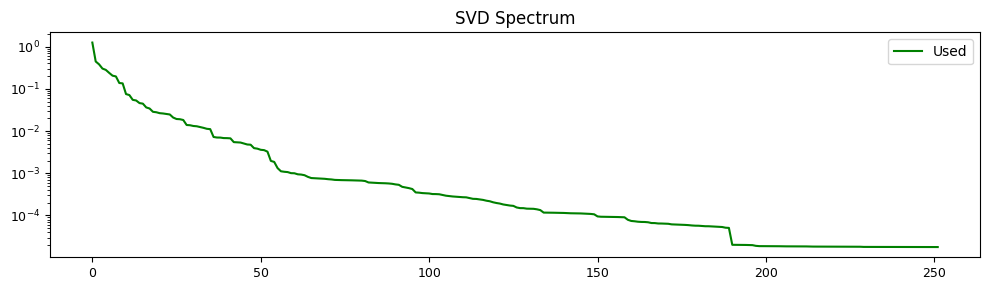

  LM inner 1: chi² 8.2507e-12 (previous 8.2515e-12), λ=0.001
Chi² after correction: 8.2507e-12

==== Iteration 19/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 19)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2507e-12


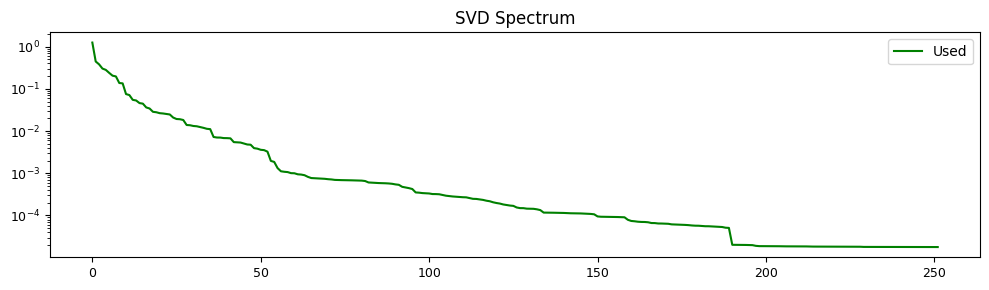

  LM inner 1: chi² 8.2500e-12 (previous 8.2507e-12), λ=0.001
Chi² after correction: 8.2500e-12

==== Iteration 20/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 20)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2500e-12


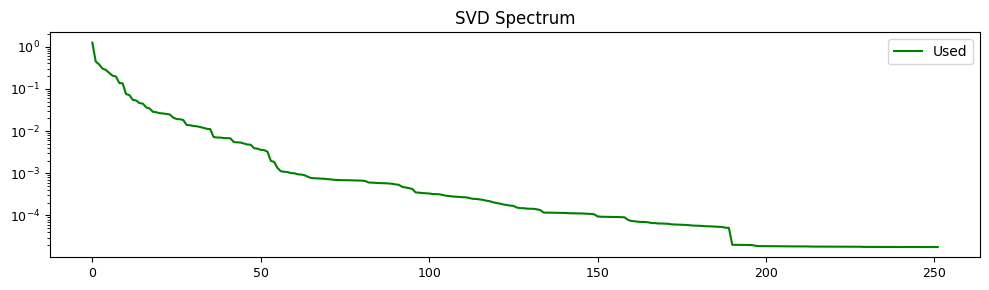

  LM inner 1: chi² 8.2494e-12 (previous 8.2500e-12), λ=0.001
Chi² after correction: 8.2494e-12

==== Iteration 21/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 21)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2494e-12


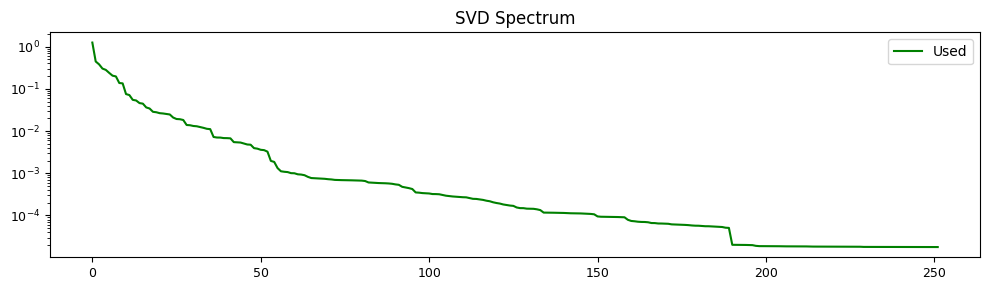

  LM inner 1: chi² 8.2488e-12 (previous 8.2494e-12), λ=0.001
Chi² after correction: 8.2488e-12

==== Iteration 22/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 22)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2488e-12


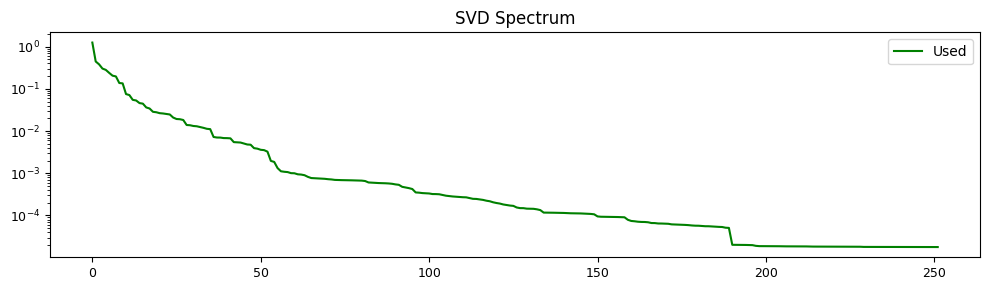

  LM inner 1: chi² 8.2484e-12 (previous 8.2488e-12), λ=0.001
Chi² after correction: 8.2484e-12

==== Iteration 23/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 23)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2484e-12


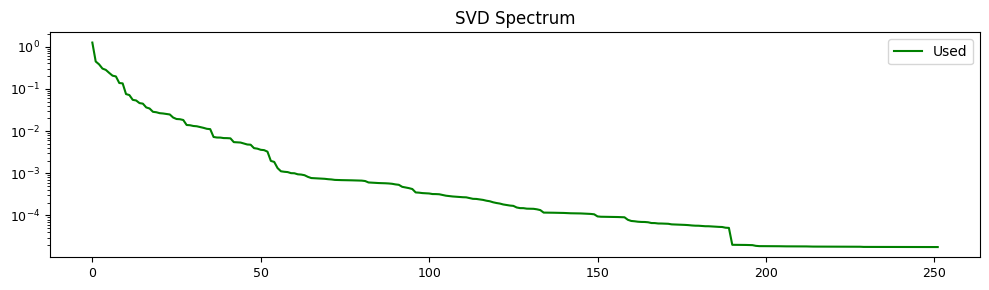

  LM inner 1: chi² 8.2480e-12 (previous 8.2484e-12), λ=0.001
Chi² after correction: 8.2480e-12

==== Iteration 24/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 24)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2480e-12


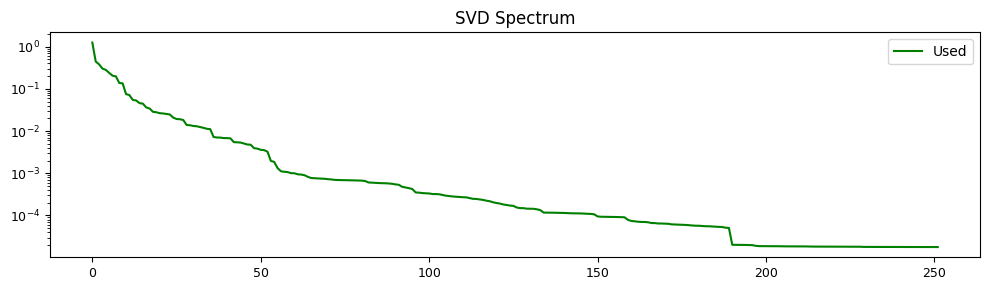

  LM inner 1: chi² 8.2476e-12 (previous 8.2480e-12), λ=0.001
Chi² after correction: 8.2476e-12

==== Iteration 25/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 25)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2476e-12


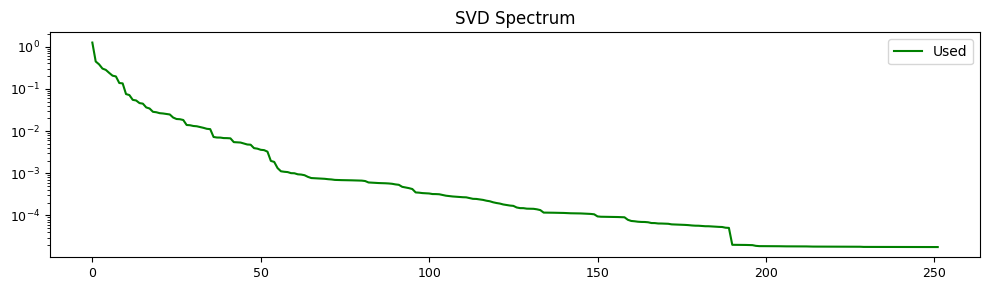

  LM inner 1: chi² 8.2472e-12 (previous 8.2476e-12), λ=0.001
Chi² after correction: 8.2472e-12

==== Iteration 26/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 26)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2472e-12


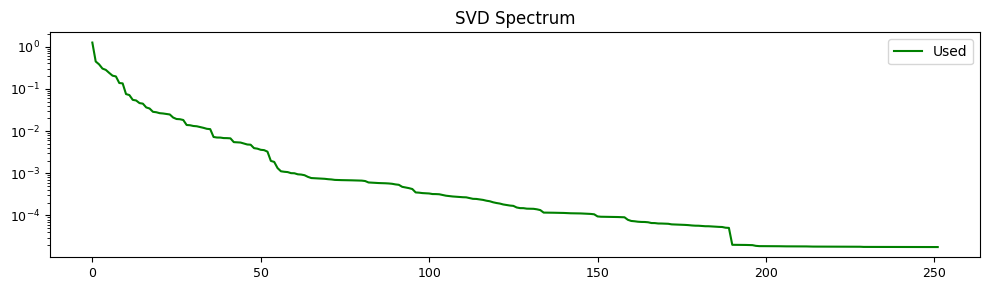

  LM inner 1: chi² 8.2469e-12 (previous 8.2472e-12), λ=0.001
Chi² after correction: 8.2469e-12

==== Iteration 27/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 27)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2469e-12


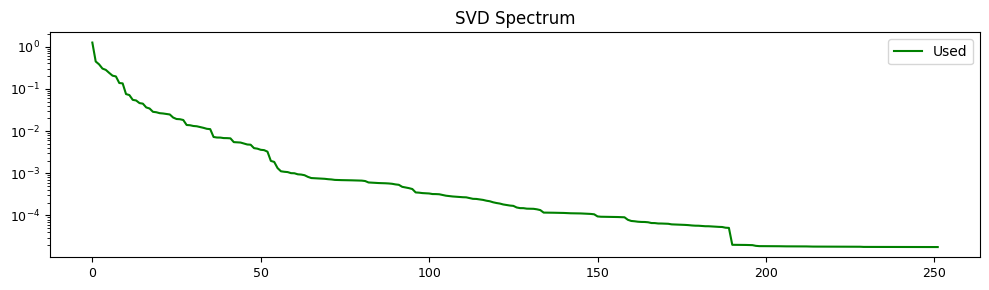

  LM inner 1: chi² 8.2467e-12 (previous 8.2469e-12), λ=0.001
Chi² after correction: 8.2467e-12

==== Iteration 28/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 28)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2467e-12


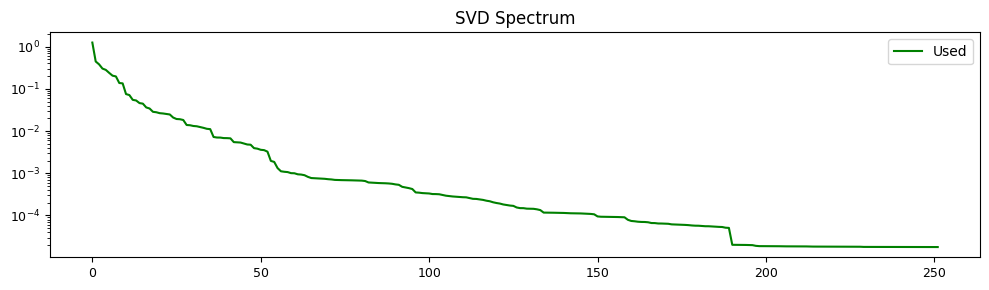

  LM inner 1: chi² 8.2464e-12 (previous 8.2467e-12), λ=0.001
Chi² after correction: 8.2464e-12

==== Iteration 29/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 29)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2464e-12


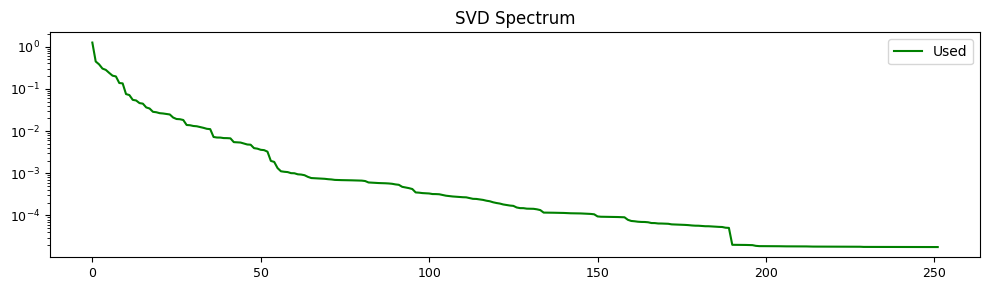

  LM inner 1: chi² 8.2462e-12 (previous 8.2464e-12), λ=0.001
Chi² after correction: 8.2462e-12

==== Iteration 30/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 30)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2462e-12


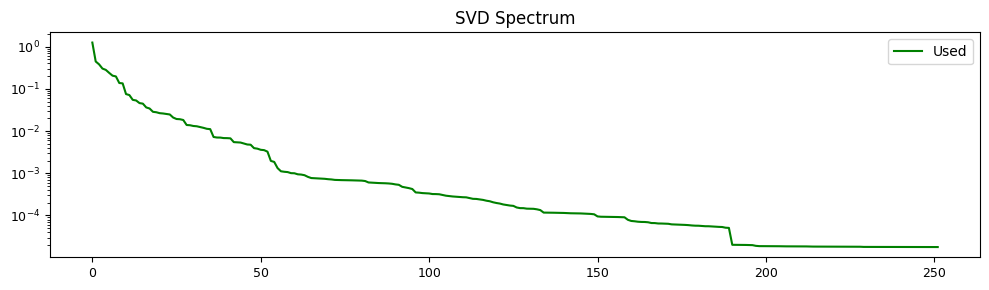

  LM inner 1: chi² 8.2459e-12 (previous 8.2462e-12), λ=0.001
Chi² after correction: 8.2459e-12

==== Iteration 31/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 31)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2459e-12


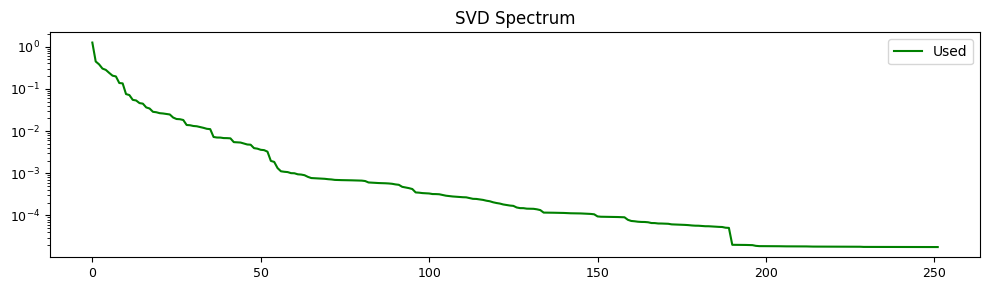

  LM inner 1: chi² 8.2457e-12 (previous 8.2459e-12), λ=0.001
Chi² after correction: 8.2457e-12

==== Iteration 32/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 32)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2457e-12


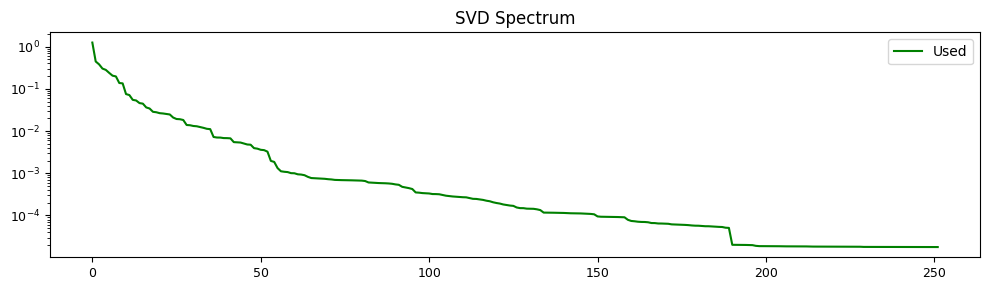

  LM inner 1: chi² 8.2455e-12 (previous 8.2457e-12), λ=0.001
Chi² after correction: 8.2455e-12

==== Iteration 33/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 33)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2455e-12


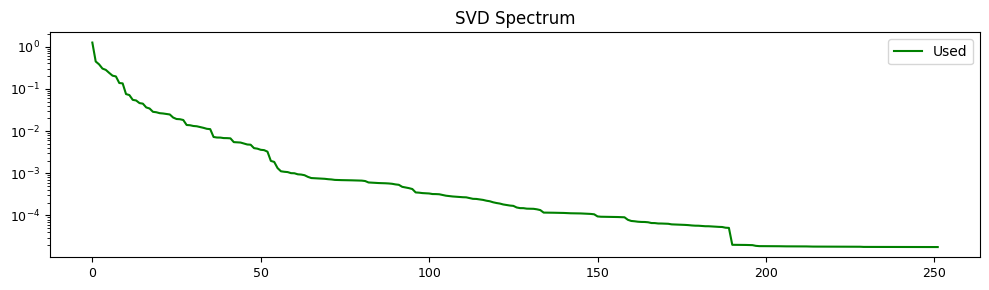

  LM inner 1: chi² 8.2454e-12 (previous 8.2455e-12), λ=0.001
Chi² after correction: 8.2454e-12

==== Iteration 34/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 34)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2454e-12


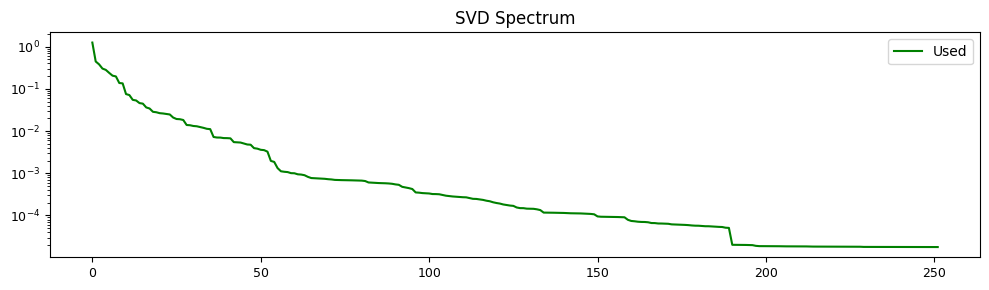

  LM inner 1: chi² 8.2452e-12 (previous 8.2454e-12), λ=0.001
Chi² after correction: 8.2452e-12

==== Iteration 35/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 35)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2452e-12


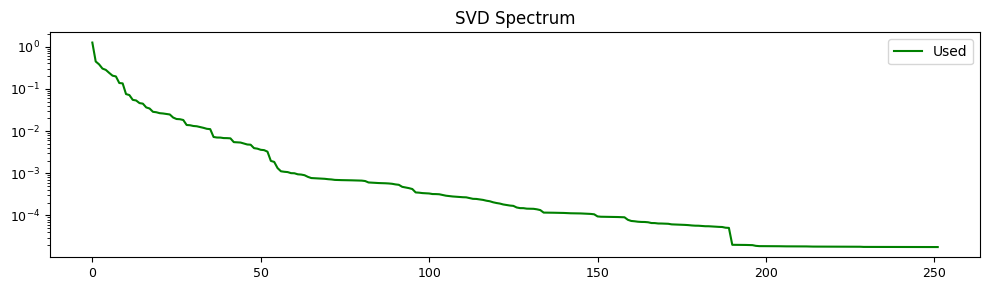

  LM inner 1: chi² 8.2450e-12 (previous 8.2452e-12), λ=0.001
Chi² after correction: 8.2450e-12

==== Iteration 36/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 36)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2450e-12


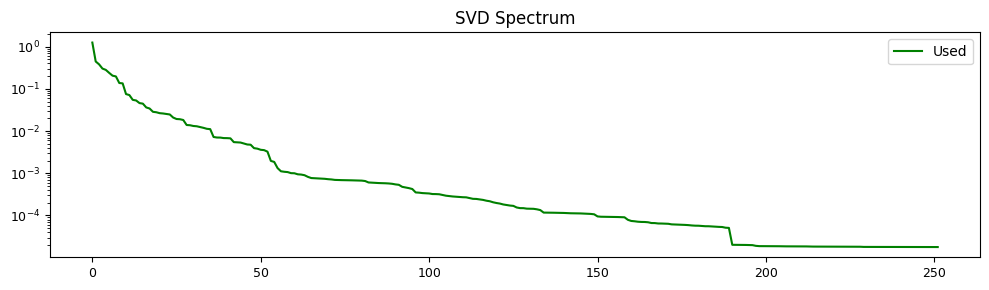

  LM inner 1: chi² 8.2449e-12 (previous 8.2450e-12), λ=0.001
Chi² after correction: 8.2449e-12

==== Iteration 37/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 37)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2449e-12


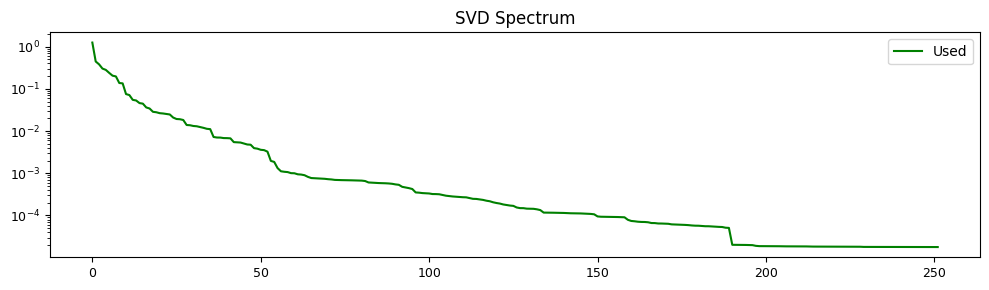

  LM inner 1: chi² 8.2448e-12 (previous 8.2449e-12), λ=0.001
Chi² after correction: 8.2448e-12

==== Iteration 38/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 38)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2448e-12


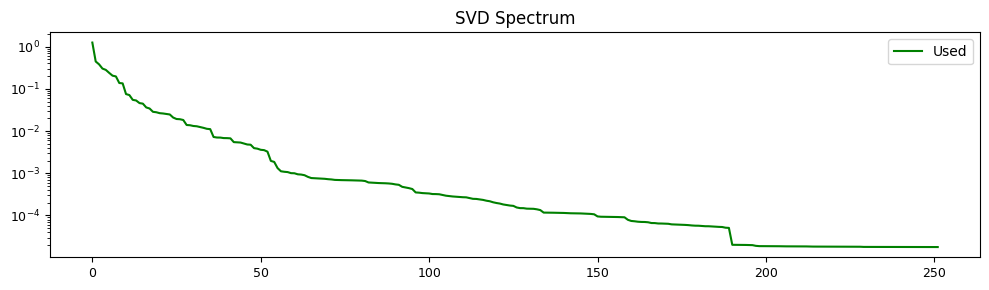

  LM inner 1: chi² 8.2446e-12 (previous 8.2448e-12), λ=0.001
Chi² after correction: 8.2446e-12

==== Iteration 39/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 39)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2446e-12


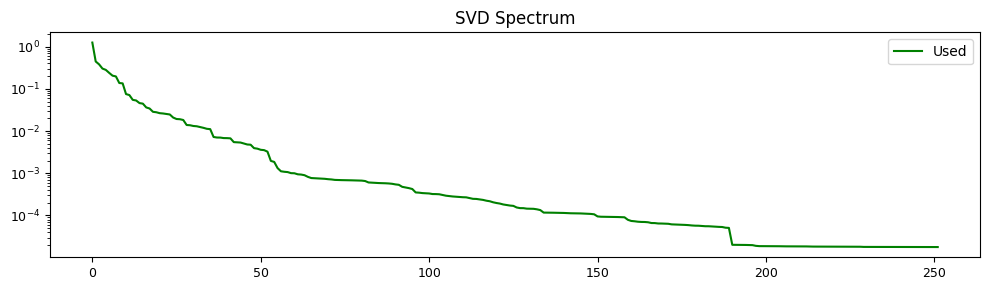

  LM inner 1: chi² 8.2445e-12 (previous 8.2446e-12), λ=0.001
Chi² after correction: 8.2445e-12

==== Iteration 40/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 40)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2445e-12


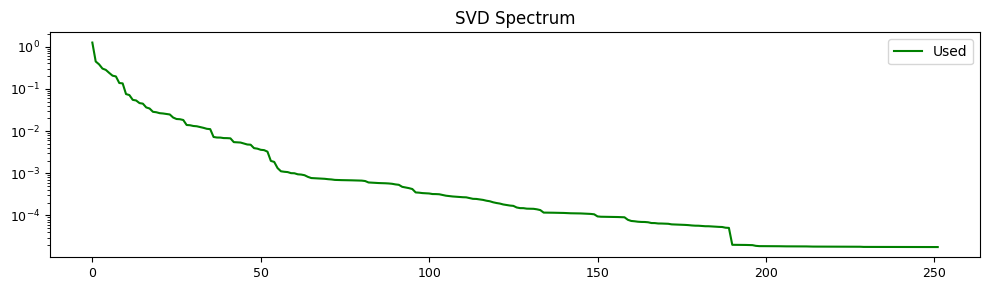

  LM inner 1: chi² 8.2444e-12 (previous 8.2445e-12), λ=0.001
Chi² after correction: 8.2444e-12

==== Iteration 41/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 41)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2444e-12


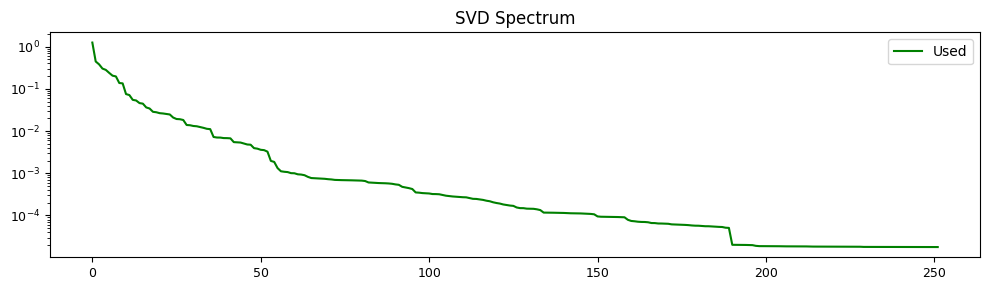

  LM inner 1: chi² 8.2443e-12 (previous 8.2444e-12), λ=0.001
Chi² after correction: 8.2443e-12

==== Iteration 42/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 42)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2443e-12


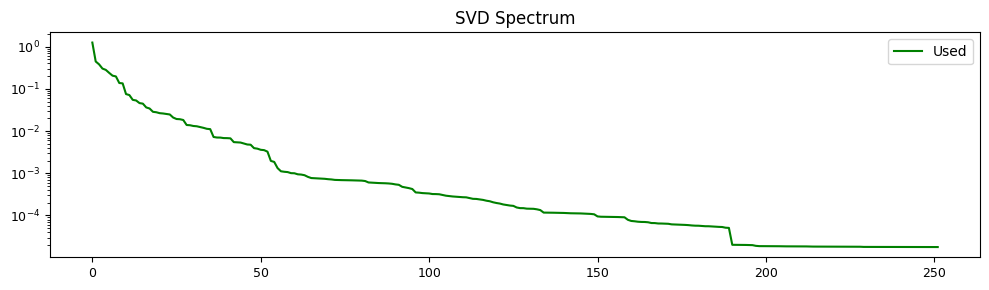

  LM inner 1: chi² 8.2442e-12 (previous 8.2443e-12), λ=0.001
Chi² after correction: 8.2442e-12

==== Iteration 43/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 43)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2442e-12


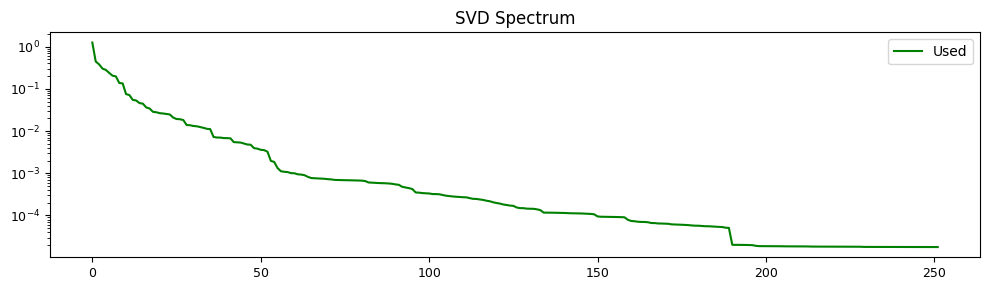

  LM inner 1: chi² 8.2441e-12 (previous 8.2442e-12), λ=0.001
Chi² after correction: 8.2441e-12

==== Iteration 44/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 44)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2441e-12


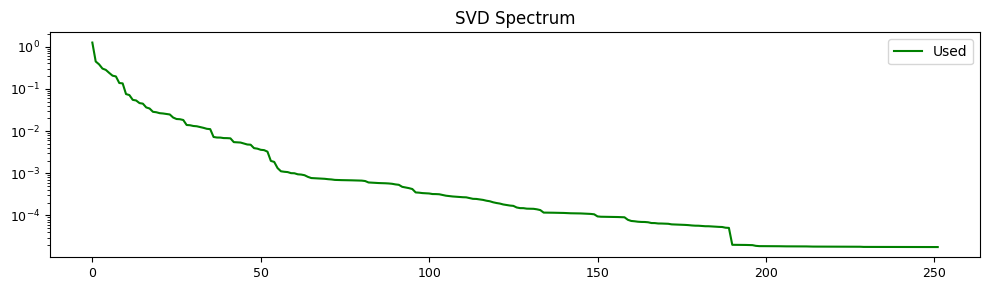

  LM inner 1: chi² 8.2440e-12 (previous 8.2441e-12), λ=0.001
Chi² after correction: 8.2440e-12

==== Iteration 45/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 45)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2440e-12


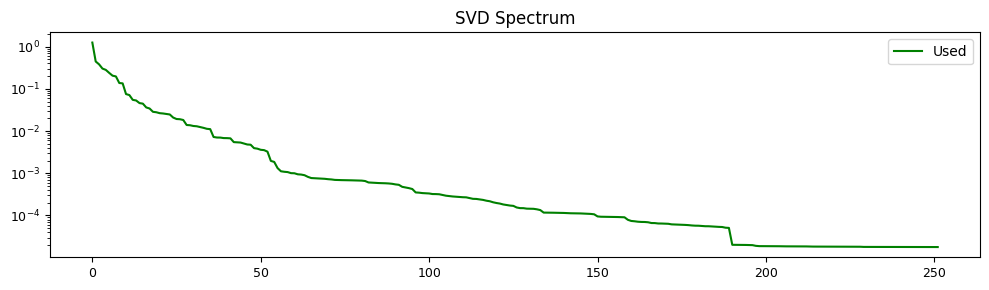

  LM inner 1: chi² 8.2439e-12 (previous 8.2440e-12), λ=0.001
Chi² after correction: 8.2439e-12

==== Iteration 46/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 46)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2439e-12


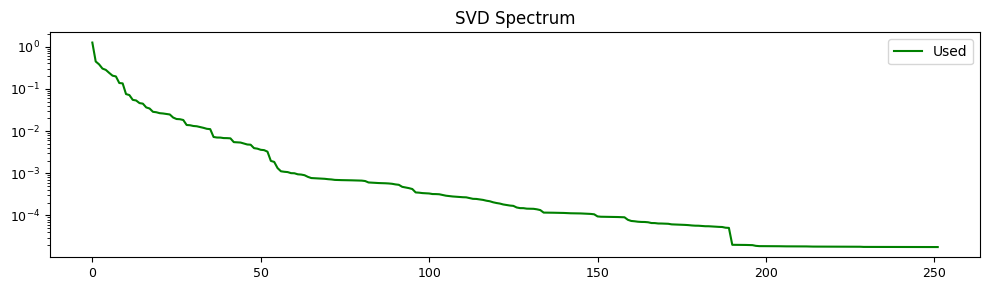

  LM inner 1: chi² 8.2438e-12 (previous 8.2439e-12), λ=0.001
Chi² after correction: 8.2438e-12

==== Iteration 47/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 47)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2438e-12


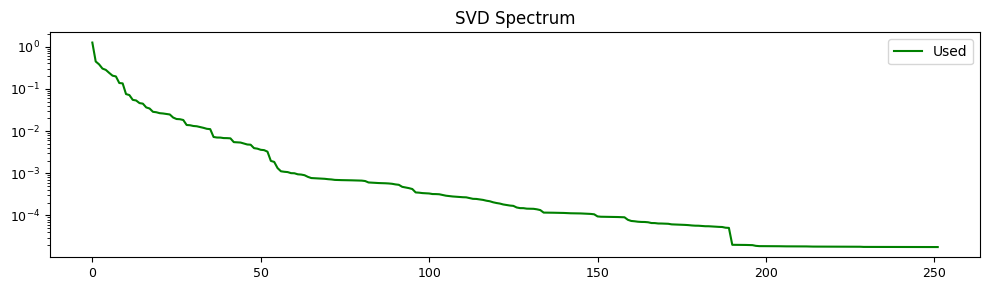

  LM inner 1: chi² 8.2437e-12 (previous 8.2438e-12), λ=0.001
Chi² after correction: 8.2437e-12

==== Iteration 48/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 48)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2437e-12


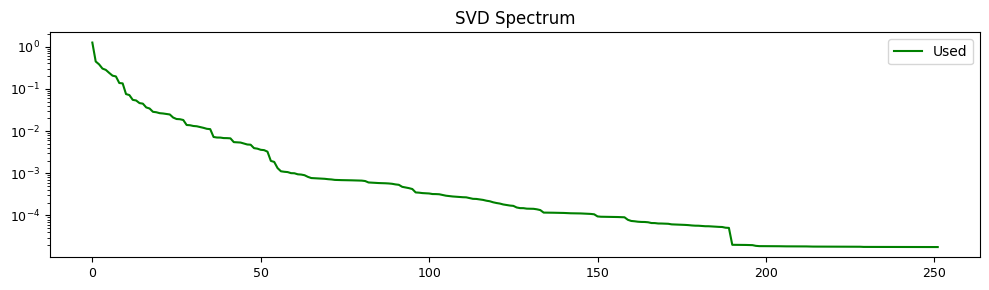

  LM inner 1: chi² 8.2436e-12 (previous 8.2437e-12), λ=0.001
Chi² after correction: 8.2436e-12

==== Iteration 49/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 49)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2436e-12


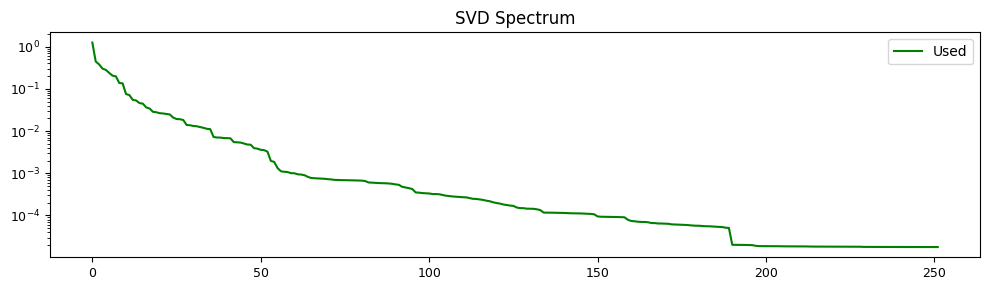

  LM inner 1: chi² 8.2435e-12 (previous 8.2436e-12), λ=0.001
Chi² after correction: 8.2435e-12

==== Iteration 50/50 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 50)...
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 8.2435e-12


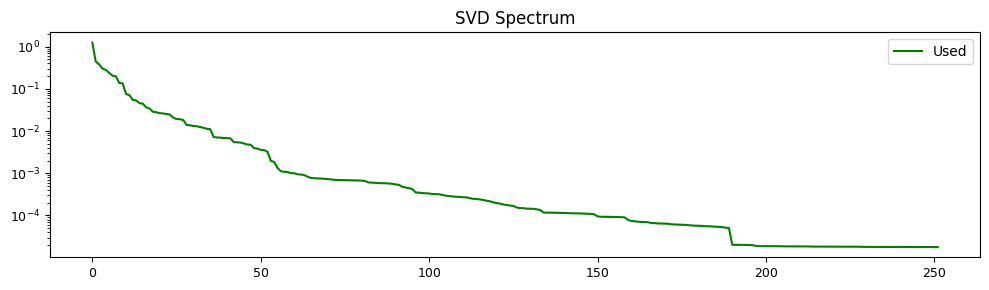

  LM inner 1: chi² 8.2434e-12 (previous 8.2435e-12), λ=0.001
Chi² after correction: 8.2434e-12
LOCO LM completed! :).
[info] Saved fit_dict to output/fit_results_all_parameters.json


In [6]:
from analyze_ring import analyze_ring

print('Before_pyLOCO_iteration')
elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

# run pyloco
#eta = np.concatenate([etax, etay])
#orm = np.hstack((orm, eta.reshape(-1, 1))) #When include_dispersion is true in the config
config_path =  os.path.abspath("pyloco_config.py")
current_fit_parameters, fit_parameters_dic, ring_pyloco = run_pyloco_from_model(
                        orm, sigma_w,  etax,  etay,  config_path=config_path
                    )

In [7]:
# apply correction

inner = last_by_sorted_key(fit_parameters_dic)
quads_fit, skew_fit = get_quads_block(inner)
delta_q = np.asarray(
[quads_fit[i] - SC.lattice.design[quad_indices[i]].K for i in range(len(quad_indices))],
dtype = float
).ravel()

In [8]:
ideal_k_1 = SC.lattice.design[quad_indices[0]].K
ideal_k_2 = SC.lattice.design[quad_indices[100]].K

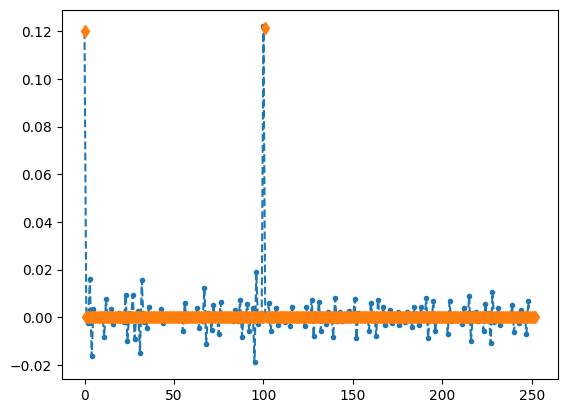

In [9]:
len(quad_indices)
measurment_err = []

for i in quad_indices:
    if i == quad_indices[0]:
        measurment_err.append(0.05 * ideal_k_1)

    if i == quad_indices[100]:
        measurment_err.append(0.05 * ideal_k_2)

    else:
        measurment_err.append(0)
loco_fit = delta_q
plt.plot(loco_fit,'.--')
plt.plot(measurment_err,'d')

In [10]:
#delta_skew = np.asarray(
#[skew_fit[i] - SC.lattice.design[skew_ord[i]].K for i in range(len(skew_ord))],
#dtype = float
#).ravel()

set_correction(SC, -delta_q, quad_indices, individuals=True, skewness=False)
#set_correction(SC, -delta_skew, skew_ord, individuals=True, skewness=True)

print('After_pyLOCO_iteration')
_, _, twiss0 = at.get_optics(SC.lattice.design, elements_ind)
analyze_ring(SC, twiss0, elements_ind, useIdealRing=False, makeplot=False)

After_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   3.7904 µm
RMS vertical orbit           :   0.0000 µm
RMS horizontal beta beating  :   1.0918 %
RMS vertical beta beating    :   0.3257 %
RMS horizontal dispersion err:   0.4633 mm
RMS vertical dispersion err  :   0.0000 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61568527e+01 2.73409875e+01 3.68191024e-03]
Chromaticity                 : [7.35295964e+00 7.55457358e+00 4.97377878e-03]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 141.10954850031598 emittance_v 0.0
----------------------------------------------------------------------
